# Import necessary libraries

In [33]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModelForImageClassification, AutoImageProcessor, AutoConfig
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import shutil
import os
import time
import tkinter as tk
from tkinter import filedialog
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from transformers import ViTForImageClassification, SwinForImageClassification
from torchvision.utils import make_grid


# Set paths for data

In [2]:
# Set paths for data
base_dir = "../frames"  # Updated to correct project structure
real_dir = os.path.join(base_dir, "real")
fake_dir = os.path.join(base_dir, "fake")
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# extracting frames

In [6]:
def extract_frames(video_path, output_folder, frame_rate=10):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print(f"Warning: {video_path} has no frames.")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_rate == 0:
            frame_filename = os.path.join(output_folder, f"{os.path.basename(video_path).split('.')[0]}_frame{frame_count}.jpg")
            cv2.imwrite(frame_filename, frame)
        frame_count += 1

    cap.release()

def limit_videos(video_paths, limit, random_selection=True):
    if random_selection:
        return random.sample(video_paths, min(limit, len(video_paths)))
    else:
        return video_paths[:limit]


# --- Video Limiting Integration with Data Loading ---

In [7]:

# --- Video Limiting Integration with Data Loading ---

real_dir = "../../data/real"
fake_dir = "../../data/fake"

real_videos = [os.path.join(real_dir, vid) for vid in os.listdir(real_dir) if vid.endswith(('.mp4', '.avi', '.mov'))]
fake_videos = [os.path.join(fake_dir, vid) for vid in os.listdir(fake_dir) if vid.endswith(('.mp4', '.avi', '.mov'))]



# Limiting videos for computational efficiency

In [8]:
# Limiting videos for computational efficiency
limit = 50  # Set the limit for videos
real_videos = limit_videos(real_videos, limit)
fake_videos = limit_videos(fake_videos, limit)

print(f"Number of real videos used: {len(real_videos)}")
print(f"Number of fake videos used: {len(fake_videos)}")

Number of real videos used: 50
Number of fake videos used: 50


# --- Extract Frames from Limited Videos ---

In [9]:
# --- Extract Frames from Limited Videos ---

base_dir = '../../frames'
for category, video_list in zip(['real', 'fake'], [real_videos, fake_videos]):
    output_folder = os.path.join(base_dir, category)
    os.makedirs(output_folder, exist_ok=True)

    for video_path in video_list:
        extract_frames(video_path, output_folder)

In [10]:
def split_data(source_dir, train_dir, val_dir, split_ratio=0.8):
    """
    Splits data from the source directory into training and validation directories.
    
    Args:
        source_dir (str): The path to the source directory containing the data.
        train_dir (str): The path to the directory where training data will be stored.
        val_dir (str): The path to the directory where validation data will be stored.
        split_ratio (float): The ratio of data to be used for training (default is 0.8).
    """
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    
    all_files = os.listdir(source_dir)
    random.shuffle(all_files)
    
    train_count = int(len(all_files) * split_ratio)
    train_files = all_files[:train_count]
    val_files = all_files[train_count:]

    for file_name in train_files:
        shutil.move(os.path.join(source_dir, file_name), os.path.join(train_dir, file_name))
    
    for file_name in val_files:
        shutil.move(os.path.join(source_dir, file_name), os.path.join(val_dir, file_name))

    print(f"Training data: {len(train_files)} files")
    print(f"Validation data: {len(val_files)} files")


# --- Train/Val Split ---

In [11]:
# --- Train/Val Split ---

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

split_data(os.path.join(base_dir, 'real'), os.path.join(train_dir, 'real'), os.path.join(val_dir, 'real'))
split_data(os.path.join(base_dir, 'fake'), os.path.join(train_dir, 'fake'), os.path.join(val_dir, 'fake'))

Training data: 1411 files
Validation data: 353 files
Training data: 1383 files
Validation data: 346 files


# TensorBoard writer

In [3]:
# TensorBoard writer
writer = SummaryWriter("runs/hybrid_experiment")

# Set device

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Augmentation

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])


## Updated data directory paths

In [6]:
## Updated data directory paths
train_dir = "../../frames/train"
val_dir = "../../frames/val"
test_dir = "../../frames/test"

# Define Transforms and Real Data Loaders

In [7]:
# ============================
# Define Transforms and Real Data Loaders
# ============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False)
print("✅ Data transforms, training, and validation loaders defined")

✅ Data transforms, training, and validation loaders defined


# CNN Model Definition

In [8]:
# ============================
# Custom CNN Model with Dropout
# ============================
class CustomCNN(nn.Module):
    def __init__(self, input_channels=3):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        self._to_linear = None
        self.convs(torch.rand(1, input_channels, 224, 224))
        self.fc = nn.Linear(self._to_linear, 256)

    def convs(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        if self._to_linear is None:
            self._to_linear = x.view(x.size(0), -1).shape[1]
        return x

    def forward(self, x):
        x = self.convs(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print("✅ CustomCNN model defined")


✅ CustomCNN model defined


# Load Hybrid model 

In [9]:
# ============================
# Hybrid Ensemble Model
# ============================
class HybridEnsemble(nn.Module):
    def __init__(self, swin_model, cnn_model, vit_model, swin_weight=0.4, cnn_weight=0.3, vit_weight=0.3):
        super(HybridEnsemble, self).__init__()
        self.swin = swin_model
        self.cnn = cnn_model
        self.vit = vit_model
        self.swin_weight = swin_weight
        self.cnn_weight = cnn_weight
        self.vit_weight = vit_weight
        self.fc = nn.Linear(260, 2)  # 2 + 256 + 2

    def forward(self, pixel_values, x_cnn):
        swin_features = self.swin(pixel_values=pixel_values).logits
        vit_features = self.vit(pixel_values=pixel_values).logits
        cnn_features = self.cnn(x_cnn)

        combined = torch.cat([
            swin_features * self.swin_weight,
            cnn_features * self.cnn_weight,
            vit_features * self.vit_weight
        ], dim=1)
        return self.fc(combined)

print("✅ HybridEnsemble model defined")


✅ HybridEnsemble model defined


# Initialize Models

In [10]:
# ============================
# Initialize Models
# ============================
swin_config = AutoConfig.from_pretrained("microsoft/swin-tiny-patch4-window7-224", num_labels=2)
swin_model = AutoModelForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    config=swin_config,
    ignore_mismatched_sizes=True
)
swin_processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

vit_config = AutoConfig.from_pretrained("google/vit-base-patch16-224", num_labels=2)
vit_model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    config=vit_config,
    ignore_mismatched_sizes=True
)
vit_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

cnn_model = CustomCNN().to(device)
hybrid_model = HybridEnsemble(swin_model, cnn_model, vit_model).to(device)
print("✅ All models initialized")


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly

✅ All models initialized


# Define Loss, Optimizer, Scheduler

In [11]:
# ============================
# Define Loss, Optimizer, Scheduler
# ============================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
print("✅ Loss function, optimizer, and scheduler defined")


✅ Loss function, optimizer, and scheduler defined


# Training Loop 

In [21]:

# ============================
# Training Loop
# ============================
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    start_time = time.time()
    hybrid_model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", colour="green")

    for images, labels in progress_bar:
        cnn_inputs = images.to(device)
        pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
        pixel_values = swin_processor(pil_images, return_tensors="pt").pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = hybrid_model(pixel_values=pixel_values, x_cnn=cnn_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    writer.add_scalar("Loss/train", avg_loss, epoch)
    elapsed_time = time.time() - start_time

    print(f"✅ Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}, Time: {elapsed_time:.2f}s")

print("📉 Training complete and losses collected")


Epoch 1/5:   0%|          | 0/466 [00:00<?, ?it/s]

✅ Epoch 1, Avg Loss: 1.6461, Time: 3885.24s


Epoch 2/5:   0%|          | 0/466 [00:00<?, ?it/s]

✅ Epoch 2, Avg Loss: 0.3965, Time: 3702.57s


Epoch 3/5:   0%|          | 0/466 [00:00<?, ?it/s]

✅ Epoch 3, Avg Loss: 0.2698, Time: 3652.10s


Epoch 4/5:   0%|          | 0/466 [00:00<?, ?it/s]

✅ Epoch 4, Avg Loss: 0.2512, Time: 3645.12s


Epoch 5/5:   0%|          | 0/466 [00:00<?, ?it/s]

✅ Epoch 5, Avg Loss: 0.2489, Time: 3646.27s
📉 Training complete and losses collected


# Save Models and Results

In [22]:
# ----------------------
# Save Models and Results
# ----------------------

os.makedirs("../../HybridEnsemble", exist_ok=True)

torch.save(cnn_model.state_dict(), "../../HybridEnsemble/cnn_model.pth")
torch.save(vit_model.state_dict(), "../../HybridEnsemble/vit_model.pth")
torch.save(swin_model.state_dict(), "../../HybridEnsemble/swin_model.pth")
torch.save(hybrid_model.state_dict(), "../../HybridEnsemble/hybrid_model.pth")



print("✅ Models saved successfully!")


✅ Models saved successfully!


# Plot Training Loss

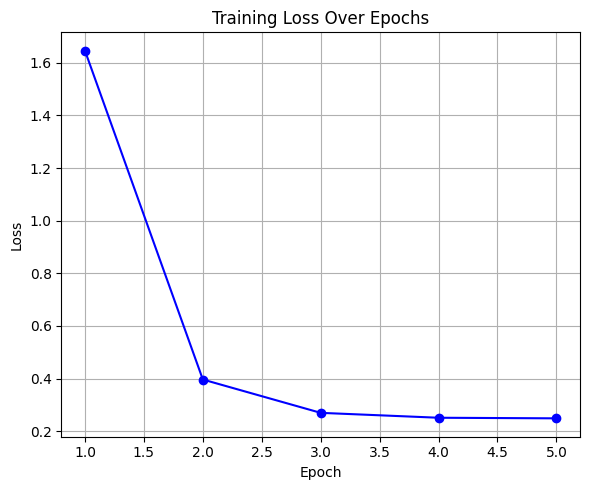

📊 Training loss plot saved and shown


In [23]:

# ============================
# Plot Training Loss
# ============================
plt.figure(figsize=(6, 5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss_plot.png")
plt.show()
print("📊 Training loss plot saved and shown")


# Accuracy Function

In [27]:
def evaluate_model_performance(model, dataloader, processor, device, dataset_name="Validation"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            images, labels = images.to(device), labels.to(device)

            # Convert images to pixel values using the processor
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = processor(pil_images, return_tensors="pt").pixel_values.to(device)

            outputs = model(pixel_values=pixel_values, x_cnn=images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n✅ {dataset_name} Accuracy: {accuracy:.2f}%")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
    print(f"📊 {dataset_name} Classification Report:\n{report}")

    return accuracy, report


In [28]:
# Evaluate on training set
evaluate_model_performance(hybrid_model, train_loader, swin_processor, device, dataset_name="Training")

# Evaluate on validation set
evaluate_model_performance(hybrid_model, val_loader, swin_processor, device, dataset_name="Validation")


Evaluating Training:   0%|          | 0/466 [00:00<?, ?it/s]


✅ Training Accuracy: 98.32%
📊 Training Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      1383
        Fake       0.97      0.99      0.98      1411

    accuracy                           0.98      2794
   macro avg       0.98      0.98      0.98      2794
weighted avg       0.98      0.98      0.98      2794



Evaluating Validation:   0%|          | 0/117 [00:00<?, ?it/s]


✅ Validation Accuracy: 95.71%
📊 Validation Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.92      0.96       346
        Fake       0.93      0.99      0.96       353

    accuracy                           0.96       699
   macro avg       0.96      0.96      0.96       699
weighted avg       0.96      0.96      0.96       699



(np.float64(95.70815450643777),
 '              precision    recall  f1-score   support\n\n        Real       0.99      0.92      0.96       346\n        Fake       0.93      0.99      0.96       353\n\n    accuracy                           0.96       699\n   macro avg       0.96      0.96      0.96       699\nweighted avg       0.96      0.96      0.96       699\n')

# Test frame extraction

In [16]:
def extract_frames(video_path, output_folder, frame_rate=30):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print(f"Warning: {video_path} has no frames.")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_rate == 0:
            frame_filename = os.path.join(output_folder, f"{os.path.basename(video_path).split('.')[0]}_frame{frame_count}.jpg")
            cv2.imwrite(frame_filename, frame)
        frame_count += 1

    cap.release()

def limit_videos(video_paths, limit, random_selection=True):
    if random_selection:
        return random.sample(video_paths, min(limit, len(video_paths)))
    else:
        return video_paths[:limit]



# --- Video Limiting Integration with Data Loading ---

In [17]:

# --- Video Limiting Integration with Data Loading ---

real_dir = "../../data/test/real"
fake_dir = "../../data/test/fake"

real_videos = [os.path.join(real_dir, vid) for vid in os.listdir(real_dir) if vid.endswith(('.mp4', '.avi', '.mov'))]
fake_videos = [os.path.join(fake_dir, vid) for vid in os.listdir(fake_dir) if vid.endswith(('.mp4', '.avi', '.mov'))]



# --- Extract Frames from Limited Videos ---

In [18]:
# --- Extract Frames from Limited Videos ---

base_dir = '../../frames/test'
for category, video_list in zip(['real', 'fake'], [real_videos, fake_videos]):
    output_folder = os.path.join(base_dir, category)
    os.makedirs(output_folder, exist_ok=True)

    for video_path in video_list:
        extract_frames(video_path, output_folder)


# Define Test Dataset and Loader

In [19]:
# ============================
# Define Test Dataset and Loader
# ============================
test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=6, shuffle=False)
print("✅ Test dataset and loader defined")


✅ Test dataset and loader defined


# Real/Fake Prediction on Test Set

In [20]:

# ============================
# Real/Fake Prediction on Test Set
# ============================
def predict_real_or_fake(model, test_loader, class_names=['real', 'fake']):
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            cnn_inputs = images.to(device)
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = swin_processor(pil_images, return_tensors="pt", padding=True).pixel_values.to(device)

            outputs = model(pixel_values=pixel_values, x_cnn=cnn_inputs)
            _, predictions = torch.max(outputs, 1)

            for i in range(len(images)):
                label = class_names[labels[i]]
                pred = class_names[predictions[i]]
                print(f"Image {i+1}: Predicted = {pred}, Actual = {label}")

print("🔍 Prediction function loaded")

🔍 Prediction function loaded


# Evaluation Function

In [21]:
# ============================
# Evaluation Function
# ============================
def test_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            cnn_inputs = images.to(device)
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = swin_processor(pil_images, return_tensors="pt", padding=True).pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values, x_cnn=cnn_inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"🧪 Test Accuracy: {acc:.2f}%")
    return acc

print("🧠 Test model evaluation function ready")

🧠 Test model evaluation function ready


# Accuracy Check on Training Set

In [22]:

# ============================
# Accuracy Check on Training Set
# ============================
def check_training_accuracy(model, train_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in train_loader:
            cnn_inputs = images.to(device)
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = swin_processor(pil_images, return_tensors="pt", padding=True).pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values, x_cnn=cnn_inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"📊 Training Accuracy (Post Training): {acc:.2f}%")
    return acc

print("🧪 Training accuracy checker ready")

🧪 Training accuracy checker ready


# Prediction Visualization

In [23]:
# ============================
# Prediction Visualization
# ============================
def show_predictions(model, data_loader, class_names=['real', 'fake'], num_images=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in data_loader:
            cnn_inputs = images.to(device)
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = swin_processor(pil_images, return_tensors="pt", padding=True).pixel_values.to(device)
            outputs = model(pixel_values=pixel_values, x_cnn=cnn_inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                img = cnn_inputs[i].cpu().permute(1, 2, 0).numpy()
                plt.imshow(img)
                plt.title(f"Pred: {class_names[preds[i]]} | True: {class_names[labels[i]]}")
                plt.axis('off')
                plt.show()

                shown += 1
                if shown >= num_images:
                    return

print("🖼️ Prediction visualization function ready")


🖼️ Prediction visualization function ready


# Run Final Predictions
## Run Accuracy Evaluation
### Check Accuracy on Training Set

In [24]:

# ============================
# Run Final Predictions
# ============================
print("\n🔎 Predicting Real or Fake on Test Set:")
predict_real_or_fake(hybrid_model, test_loader)

# ============================
# Run Accuracy Evaluation
# ============================
test_model(hybrid_model, test_loader)

# ============================
# Check Accuracy on Training Set
# ============================
check_training_accuracy(hybrid_model, train_loader)


🔎 Predicting Real or Fake on Test Set:


C:\ProgramData\anaconda3\envs\deepfake\lib\site-packages\transformers\image_processing_utils.py:42: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


Image 1: Predicted = real, Actual = real
Image 2: Predicted = real, Actual = real
Image 3: Predicted = real, Actual = real
Image 4: Predicted = real, Actual = real
Image 5: Predicted = real, Actual = real
Image 6: Predicted = fake, Actual = real
Image 1: Predicted = fake, Actual = real
Image 2: Predicted = real, Actual = real
Image 3: Predicted = real, Actual = real
Image 4: Predicted = real, Actual = real
Image 5: Predicted = real, Actual = real
Image 6: Predicted = real, Actual = real
Image 1: Predicted = real, Actual = real
Image 2: Predicted = real, Actual = real
Image 3: Predicted = real, Actual = real
Image 4: Predicted = real, Actual = real
Image 5: Predicted = real, Actual = real
Image 6: Predicted = fake, Actual = real
Image 1: Predicted = fake, Actual = real
Image 2: Predicted = fake, Actual = real
Image 3: Predicted = fake, Actual = real
Image 4: Predicted = fake, Actual = real
Image 5: Predicted = fake, Actual = real
Image 6: Predicted = fake, Actual = real
Image 1: Predict

65.0

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


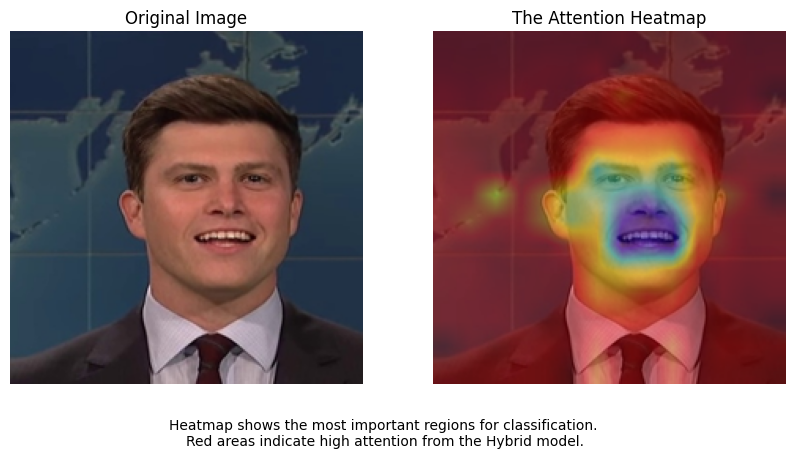

In [32]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image

# Load ViT model and processor
model_path = "../../HybridEnsemble/vit_model.pth"  # Ensure correct path
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224-in21k", num_labels=2)
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
model.eval()

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
# Function to extract attention heatmap
def generate_vit_gradcam(image_path, model):
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        attentions = outputs.attentions  # Extract attention maps

    # Take the last attention layer
    attn_map = attentions[-1].mean(dim=1).squeeze(0)  # Average over heads
    
    # Extract CLS token attention
    cls_attn = attn_map[0, 1:].reshape(14, 14)  # Reshape to 14×14 patches
    
    # Normalize and resize heatmap
    cam = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min())
    cam = cv2.resize(cam.numpy(), (224, 224))  # Resize to match input
    
    # Overlay heatmap on image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    img = np.array(image.resize((224, 224)))
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Plot results with text
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(overlay)
    ax[1].set_title("The Attention Heatmap")
    ax[1].axis("off")

    # Add text annotation
    plt.figtext(0.5, 0.02, 
                "Heatmap shows the most important regions for classification. \n"
                "Red areas indicate high attention from the Hybrid model.", 
                ha="center", fontsize=10, color="black")
    
    plt.show()

# Test with a frame
test_image = "../../frames/train/real/0002_frame20.jpg"
generate_vit_gradcam(test_image, model)




# GUI Intigration

In [25]:

# Face detector (optional)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def extract_face(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return None
    x, y, w, h = faces[0]
    face = frame[y:y+h, x:x+w]
    return face

def preprocess_frame(frame, use_face=True):
    if use_face:
        face = extract_face(frame)
        if face is None:
            return None
        frame = face
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    return transform(img)

def predict_video(model, processor, video_path, device, every_n_frames=10, max_frames=80, threshold=0.5, use_face=True):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0
    total = 0

    while cap.isOpened() and total < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if count % every_n_frames == 0:
            processed = preprocess_frame(frame, use_face)
            if processed is not None:
                frames.append(processed)
                total += 1
        count += 1
    cap.release()

    if len(frames) == 0:
        return "No frames extracted or no faces detected."

    images_tensor = torch.stack(frames).to(device)
    pil_images = [transforms.ToPILImage()(img.cpu()) for img in images_tensor]
    pixel_values = processor(pil_images, return_tensors="pt").pixel_values.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, x_cnn=images_tensor)
        probabilities = torch.softmax(outputs, dim=1)  # [N, 2]
        frame_preds = torch.argmax(probabilities, dim=1)  # predictions per frame
        majority_label = torch.mode(frame_preds).values.item()
        confidence = torch.mean(probabilities[:, majority_label]).item()

    print(f"🧠 Majority vote: {['Fake', 'Real'][majority_label]} (confidence: {confidence:.3f})")

    if confidence < threshold:
        return "Uncertain"
    return "Fake" if majority_label == 0 else "Real"


# GUI FUNCTION 

In [26]:


# ========= GUI FUNCTION =========
def launch_gui(model, processor, device):
    def load_video():
        file_path = filedialog.askopenfilename(filetypes=[("Video files", "*.mp4 *.avi *.mov")])
        if file_path:
            label_video_path.config(text=os.path.basename(file_path))
            label_result.config(text="Processing...", fg="blue")
            root.update_idletasks()
            result = predict_video(model, processor, file_path, device)
            label_result.config(text=f"Prediction: {result}", fg="green" if result == "Real" else "red")

    # GUI Window
    root = tk.Tk()
    root.title("🎬 DeepFake Video Detector")
    root.geometry("550x280")
    root.configure(bg="#f0f0f0")

    # Title
    label_title = tk.Label(root, text="DeepFake Detector GUI", font=("Helvetica", 18, "bold"), bg="#f0f0f0")
    label_title.pack(pady=15)

    # Browse Button
    btn_browse = tk.Button(root, text="Select Video File", command=load_video,
                           font=("Helvetica", 12), bg="#4CAF50", fg="white", padx=20, pady=5)
    btn_browse.pack()

    # Video Path Display
    label_video_path = tk.Label(root, text="No video selected", font=("Helvetica", 10), bg="#f0f0f0", wraplength=450)
    label_video_path.pack(pady=10)

    # Result Label
    label_result = tk.Label(root, text="", font=("Helvetica", 16, "bold"), bg="#f0f0f0")
    label_result.pack(pady=20)

    root.mainloop()


# GUI Classification function

In [27]:


def evaluate_model_performance(model, dataloader, processor, device, dataset_name="Validation"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            images, labels = images.to(device), labels.to(device)

            # Convert images to pixel values using the processor
            pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]
            pixel_values = processor(pil_images, return_tensors="pt").pixel_values.to(device)

            outputs = model(pixel_values=pixel_values, x_cnn=images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Print the full classification report
    report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
    print(f"📊 {dataset_name} Classification Report:\n{report}")


# GUI Launcher

In [28]:
launch_gui(hybrid_model, swin_processor, device)


🧠 Majority vote: Fake (confidence: 0.506)
